# 🧠 Mission 3: Understand the Data

```{admonition} Your mission
:class: tip

You have inspected the replication package. Now it is time to understand the data itself.

In this mission, you will:

- 📊 explore the dataset structure
- 🧾 identify important variables
- 🌳 understand key canopy indicators
- 🧠 connect values with their meaning

🏅 **Badge to unlock:** Data Interpreter

# 🔎 Open the main spatial dataset

Mission 2 identified the GeoPackages as the main spatial data.

>For our investigation, we will focus on the **Berlin dataset**, which contains urban forest and building indicators for 100 m grid cells.

In [4]:
import geopandas as gpd
from pathlib import Path

data_dir = Path("data/g_raw")

berlin_file = (
    data_dir
    / "berlin_3D_canopy_stats_lczv3_grid100m_urau2021_epsg25833.gpkg"
)

berlin = gpd.read_file(berlin_file)

/opt/conda/envs/worker_env/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


```{note}
You may see a warning about a **Measured 3D MultiPolygon** being converted to `MultiPolygon Z`.

This is not an error. The dataset still loads successfully; only the unsupported measure (`M`) dimension is removed.

# 👀 Take a first look

Before analysing individual indicators, let's inspect the first few observations.

In [5]:
berlin.head()

,tile_id,centroid_x,centroid_y,cell_area,lcz_class_value,chm_area,chm_volume,bldg_area,bldg_volume,geometry
0,3969_58220,396950.0,5822050.0,10000.0,0,1952.75,15642.54,522.25,7440.57,"MULTIPOLYGON (((397000 5822000, 396900 5822000..."
1,3969_58221,396950.0,5822150.0,10000.0,0,974.50,7245.98,5470.00,76521.83,"MULTIPOLYGON (((397000 5822100, 396900 5822100..."
2,3969_58222,396950.0,5822250.0,10000.0,0,204.00,1510.19,6977.50,97985.20,"MULTIPOLYGON (((397000 5822200, 396900 5822200..."
3,3969_58223,396950.0,5822350.0,10000.0,0,871.25,9699.76,2929.25,28673.67,"MULTIPOLYGON (((397000 5822300, 396900 5822300..."
4,3970_58220,397050.0,5822050.0,10000.0,0,1610.00,15820.57,2557.25,40974.82,"MULTIPOLYGON (((397100 5822000, 397093 5822000..."


# 🧩 Rows and columns

The table has two basic building blocks:

>- each **row** represents a 100 m grid cell
>- each **column** describes a characteristic of that cell

Let's see which attributes are available.

In [6]:
berlin.columns.tolist()

['tile_id',
 'centroid_x',
 'centroid_y',
 'cell_area',
 'lcz_class_value',
 'chm_area',
 'chm_volume',
 'bldg_area',
 'bldg_volume',
 'geometry']

# 🧾 Decode the variables

The column names give us clues about what each grid cell describes.

| Variable | Meaning |
|---|---|
| `tile_id` | Grid-cell identifier |
| `centroid_x`, `centroid_y` | Location of the cell centre |
| `cell_area` | Area of the grid cell |
| `lcz_class_value` | Local Climate Zone class |
| `chm_area` | Canopy-covered area |
| `chm_volume` | 3D canopy volume |
| `bldg_area` | Building-covered area |
| `bldg_volume` | 3D building volume |
| `geometry` | Spatial shape of the grid cell |

For our urban forest investigation, two variables are especially interesting:

🌿 **`chm_area`** — horizontal canopy coverage  
🌳 **`chm_volume`** — three-dimensional canopy structure

```{admonition} 🕵️ Follow the clue
:class: note

Imagine two grid cells have the same `chm_area`.

Could they still have different `chm_volume` values?

**Yes.** Similar canopy coverage can contain vegetation with different vertical structures.

This distinction will become important later in the investigation.

# 🔬 Inspect the canopy indicators

Let's summarise our two key indicators before using them in further analysis.

In [7]:
canopy_indicators = [
    "chm_area",
    "chm_volume"
]

berlin[canopy_indicators].describe().T

,count,mean,std,min,25%,50%,75%,max
chm_area,90530.0,3961.142977,2910.194627,0.0,1852.25,3266.25,5639.000,9993.75
chm_volume,90530.0,57624.795022,62298.854941,0.0,14374.67,32292.82,75916.965,297611.28


# 🔍 Read the summary

Focus on four values:

>- **min** → smallest observed value
>- **mean** → average
>- **50%** → median or middle value
>- **max** → largest observed value

The range from minimum to maximum already tells us that canopy structure varies considerably between grid cells.

But a table can only take us so far.

# 📊 Look at canopy volume

A histogram helps us see how `chm_volume` values are distributed across the dataset.

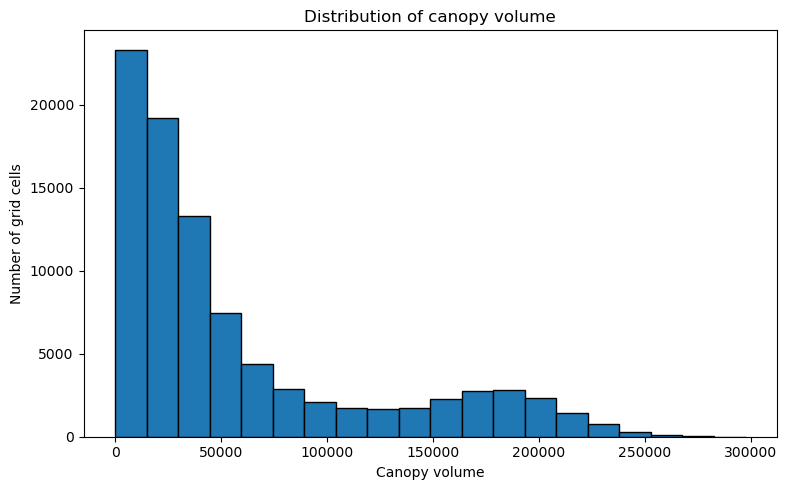

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

berlin["chm_volume"].plot(
    kind="hist",
    bins=20,
    edgecolor="black",
    ax=ax
)

ax.set_title("Distribution of canopy volume")
ax.set_xlabel("Canopy volume")
ax.set_ylabel("Number of grid cells")

plt.tight_layout()
plt.show()

```{admonition} 🔍 Evidence check
:class: note

Look at the shape of the distribution.

- Are most grid cells concentrated around lower or higher values?
- Is the distribution symmetrical?
- Do some cells have much larger canopy volumes than others?

At this stage, we are **describing the pattern** — not yet explaining why it occurs.

In [11]:
#| tags: [remove-input]

from IPython.display import HTML, display
from pathlib import Path

download_dir = Path.cwd() / "_static" / "g_output"
download_dir.mkdir(parents=True, exist_ok=True)

output_png = download_dir / "distribution_of_canopy_volume.png"

fig.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight"
)

display(
    HTML(
        """
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/g_output/distribution_of_canopy_volume.png" download
       style="display: inline-block;
              background-color: #2E7D32;
              color: white;
              padding: 10px 14px;
              text-decoration: none;
              border-radius: 6px;
              font-weight: bold;">
       ⬇️ Download PNG
    </a>

</div>
"""
    )
)

# 🧠 From numbers to meaning

We now know that canopy volume varies substantially across the grid cells.

But an indicator is useful only when we understand what it represents.

For this investigation:

>**`chm_area`** tells us about the horizontal extent of canopy.

>**`chm_volume`** adds the vertical dimension and gives us information about 3D vegetation structure.

Together, they provide different perspectives on Berlin's urban forest.

```{tip}
Before analysing any indicator, ask:

**What does it measure? → What does a high or low value mean? → Why is it relevant to my question?**

Understanding the variable comes before interpreting the result.

```{raw} html
<div class="admonition tip">
  <p class="admonition-title">🎉 Mission Complete — Badge Unlocked!</p>

  <h3>🏆 Data Interpreter</h3>

  <p>You successfully decoded the dataset and its key indicators.</p>

  <ul>
    <li>✔ Dataset structure explored</li>
    <li>✔ Variables identified</li>
    <li>✔ Canopy indicators understood</li>
    <li>✔ Indicator values interpreted</li>
  </ul>

  <p><strong>Status:</strong> Mission 3 complete</p>

  <button onclick="completeMission3()"
          style="padding: 10px 16px;
                 font-weight: bold;
                 border-radius: 6px;
                 cursor: pointer;">
    ✅ Complete Mission 3
  </button>

  <p id="mission-3-complete-message"
     style="font-weight: bold; margin-top: 12px;"></p>
</div>

<script>
function completeMission3() {

  localStorage.setItem(
    "urban_data_mission_3_completed",
    "true"
  );

  localStorage.setItem(
    "urban_data_badge_3",
    "Data Interpreter"
  );

  localStorage.setItem(
    "urban_data_mission_3_completed_at",
    new Date().toISOString()
  );

  document.getElementById(
    "mission-3-complete-message"
  ).innerHTML =
    "🔓 Mission 4 unlocked! Badge added to your gallery.";
}
</script>

# 🎮 Mission Progress

**Your Journey**

🟢 Mission 1: Locate & Retrieve Data ✅  
🟢 Mission 2: Inspect the Package ✅  
🟢 **Mission 3: Understand the Data ← Current**  
⚪ Mission 4: Generate Insights 🔒  
⚪ Mission 5: Create Visual Evidence 🔒  
⚪ Mission 6: Map the City 🔒  
⚪ Mission 7: Extend the Analysis 🔒  
⚪ Final Mission: Tell the Data Story 🔒  

**Progress:** ▰▰▰▱▱▱▱▱ **3/8 Complete**

```{admonition} 🚧 Next Mission Preview
:class: note, dropdown

# 💡 Mission 4: Generate Insights

You understand the variables. Now it is time to ask **what patterns they reveal**.

You will learn how to:

- 📊 summarise key indicators
- 🔎 compare canopy characteristics
- 📈 identify meaningful differences
- 🧠 turn observations into first insights

**Your next challenge: move from understanding the data to investigating it.**